erterfrf
erteart



In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [7]:
# GLOBAL VARIABLES
DATASET_CSV_PATH = "../data/sample_dataset_csv"

#NAMES COLUMNS
TIMESTAMP = 'timestamp'
TOPIC = 'topic'
TYPE = 'type'
POSE_FROM_COV = "pose.pose."
POSITION_X = "position.x"
POSITION_Y = "position.y"
ORIENTATION_Z = 'orientation.z'
ORIENTATION_W = 'orientation.w'
COVARIANCE = "pose.covariance"

#TOPICS
AMCL_POSE = '/amcl_pose'
GROUNDTRUTH_POSE = '/groundtruth_pose'

#COLORS (this will change when the number of examples is higher)
colors = ['red', 'blue', 'green', 'orange', 'purple', 'brown']

In [49]:
# Class with the data of a ros iteration
class DatasetRos:
    def __init__(self, scenario, run_n, csv_file):
        self.scenario = scenario
        self.run_n = run_n
        self.csv_file = csv_file
        self.df = pd.read_csv(
            csv_file,
            comment='#',       
            sep=',',           
            quotechar='"',     
            engine='python'
        )
#Quaternion for 2D orentation to yaw
def quaternion_to_yaw(z, w):
    return np.arctan2(2*w*z, 1 - 2*z**2)

# Get Pose error of the scenario (2D) in form of position_error, yaw_error, timestamp
# given deduced pose info and real pose info
def get_pose_error(deduced_pose, real_pose):
    #since is 2D just take position.x and y and orientation.z and w.
    deduced_position_x = deduced_pose[POSE_FROM_COV + POSITION_X].to_numpy()
    deduced_position_y = deduced_pose[POSE_FROM_COV + POSITION_Y].to_numpy()
    deduced_orientation_z = deduced_pose[POSE_FROM_COV + ORIENTATION_Z].to_numpy()
    deduced_orientation_w = deduced_pose[POSE_FROM_COV + ORIENTATION_W].to_numpy()
    deduced_timestamp = deduced_pose[TIMESTAMP].to_numpy()

    real_position_x = real_pose[POSITION_X].to_numpy()
    real_position_y = real_pose[POSITION_Y].to_numpy()
    real_orientation_z = real_pose[ORIENTATION_Z].to_numpy()
    real_orientation_w = real_pose[ORIENTATION_W].to_numpy()
    real_timestamp = real_pose[TIMESTAMP].to_numpy()
    
    #get interpolation of real_pose to timestamp of deduced_pose.
    real_position_x_inter = np.interp(deduced_timestamp, real_timestamp, real_position_x)
    real_position_y_inter = np.interp(deduced_timestamp, real_timestamp, real_position_y)
    real_orientation_z_inter = np.interp(deduced_timestamp, real_timestamp, real_orientation_z)
    real_orientation_w_inter = np.interp(deduced_timestamp, real_timestamp, real_orientation_w)

    #now it is possible to get the vectoriced error
    dx = deduced_position_x - real_position_x_inter
    dy = deduced_position_y - real_position_y_inter
    position_error = np.sqrt(dx**2 + dy**2)
    
    #get yaw error.
    real_yaw_inter = quaternion_to_yaw(real_orientation_z_inter, real_orientation_w_inter)
    deduced_yaw = quaternion_to_yaw(deduced_orientation_z, deduced_orientation_w)
    yaw_error = deduced_yaw - real_yaw_inter
    #normalice between [-pi, pi]
    yaw_error = (yaw_error + np.pi) % (2 * np.pi) - np.pi

    return position_error, yaw_error, deduced_timestamp

# Get dispersion of the position and orientation (2D) and  from deduced pose rows in form disp_pos, disp_yaw, timestamp
def get_disp_covariance(deduced_pose):
    disp_poss = []
    disp_yaws = []
    covariances_str = deduced_pose[COVARIANCE].to_numpy()
    timestamp = deduced_pose[TIMESTAMP].to_numpy()
    
    for covariance_str in covariances_str:
        #get the matrix from the string
        covariance = np.fromstring(covariance_str.replace('\n', ' ').replace('[', '').replace(']', ''), sep=' ')
        size = int(np.sqrt(len(covariance)))
        cov_matrix = covariance.reshape(size, size)
        
        disp_pos = np.linalg.det(cov_matrix[:2, :2])
        disp_yaw = cov_matrix[5,5]
        
        disp_poss.append(disp_pos)
        disp_yaws.append(disp_yaw)
    return disp_poss, disp_yaws, timestamp

cmap = plt.get_cmap('tab10')

In [50]:
#Get dataset
dataset = []

for csv_file in os.listdir(DATASET_CSV_PATH):
    if csv_file.endswith(".csv"):
        full_path = os.path.join(DATASET_CSV_PATH, csv_file)
        #Get map_name and run
        name = csv_file[:-4] #delete .csv
        name_parts = name.rsplit('-', 1)
        scenario = name_parts[0]
        run_n = int(name_parts[1])
        is_new_scenario = True
        #Group by scenarios
        for scenario_group in dataset:
            if scenario_group[0].scenario == scenario:
                scenario_group.append(DatasetRos(scenario, run_n, full_path))
                is_new_scenario = False
        if is_new_scenario:
            scenario_group = []
            scenario_group.append(DatasetRos(scenario, run_n, full_path))
            dataset.append(scenario_group)    

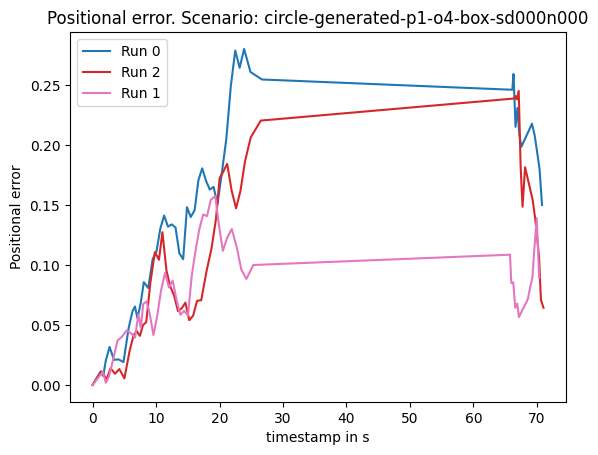

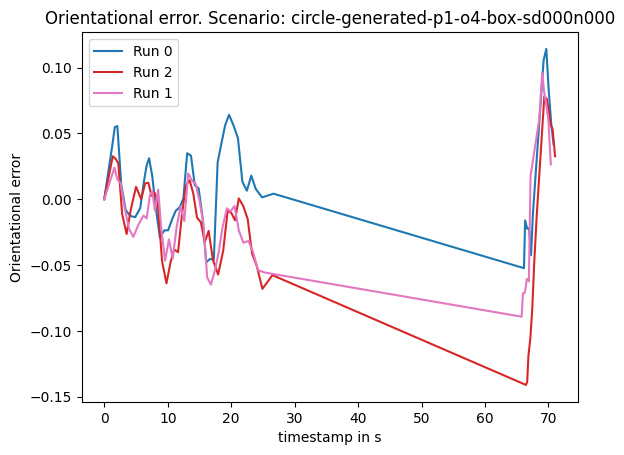

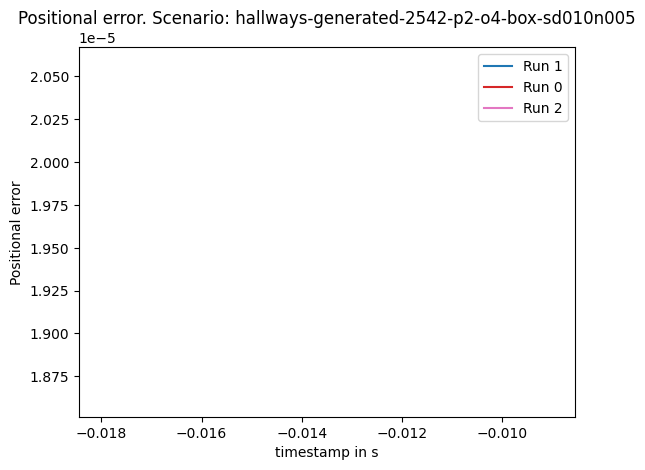

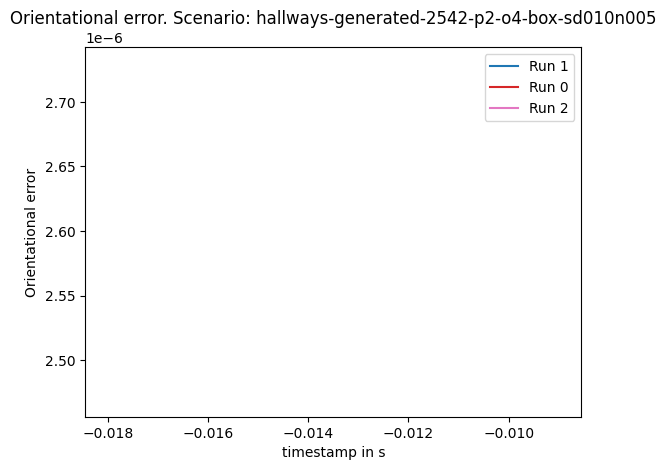

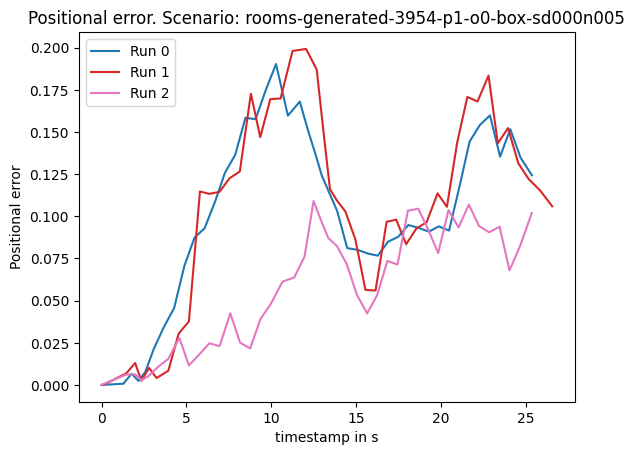

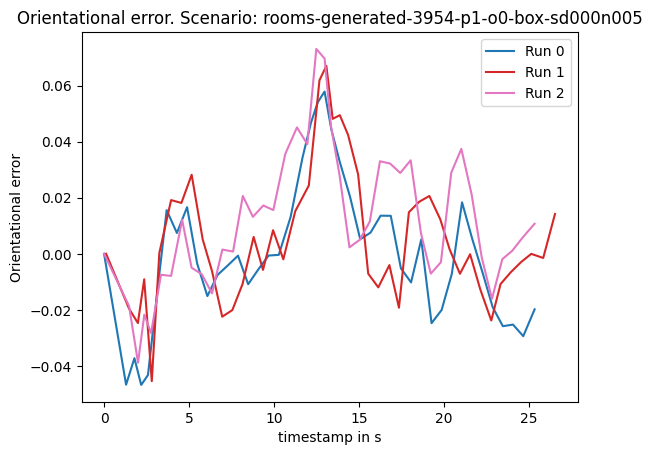

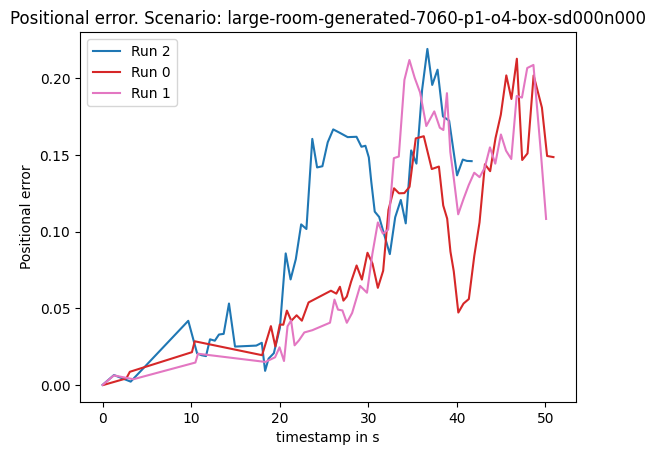

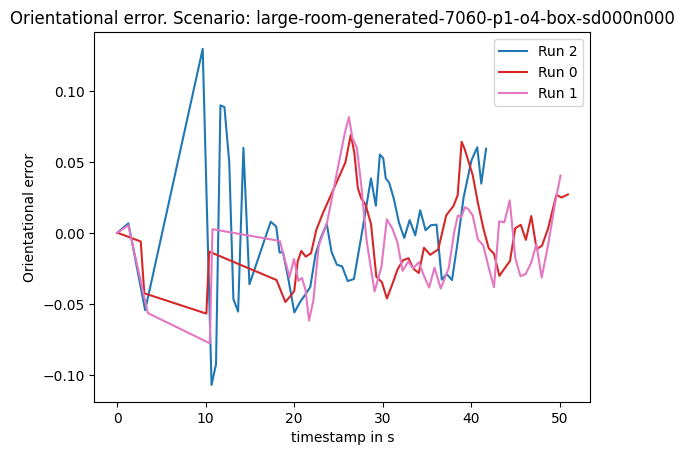

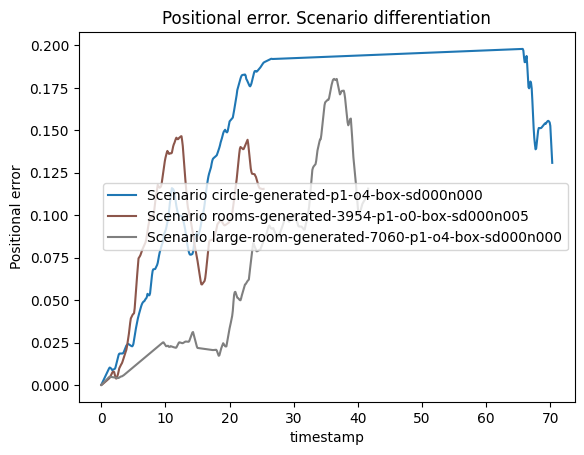

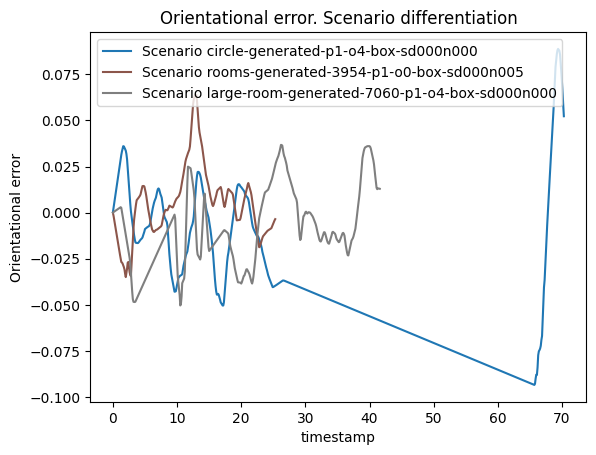

In [51]:
#Analysis of deduced pose with real pose (localization)

#figure for means position
plt.figure(0)
plt.title('Positional error. Scenario differentiation')
plt.xlabel(TIMESTAMP)
plt.ylabel('Positional error')
#figure for means orientation
plt.figure(1)
plt.title('Orientational error. Scenario differentiation')
plt.xlabel(TIMESTAMP)
plt.ylabel('Orientational error')

for i, scenario_group in enumerate(dataset):
    #first two for means, and we want two figures per scenario
    pos_f = 2 + i*2 
    or_f = 2 + i*2 + 1
    #figure for scenario position
    plt.figure(pos_f) 
    plt.title('Positional error. Scenario: ' +  scenario_group[0].scenario)
    plt.xlabel(TIMESTAMP + " in s")
    plt.ylabel('Positional error')
    #figure for scenario orientation
    plt.figure(or_f)
    plt.title('Orientational error. Scenario: ' +  scenario_group[0].scenario)
    plt.xlabel(TIMESTAMP + " in s")
    plt.ylabel('Orientational error')

    # maximum time of all runs and scenarios
    t_max = []
    # sum of position and orientation error of the scenario
    position_error_sum = []
    yaw_error_sum = []
              
    for j, run in enumerate(scenario_group):
        t0 = run.df[TIMESTAMP].iloc[1]
        deduced_pose = run.df.loc[run.df[TOPIC] == AMCL_POSE]
        real_pose = run.df.loc[run.df[TOPIC] == GROUNDTRUTH_POSE]

        # get pose error
        position_error, yaw_error, timestamp = get_pose_error(deduced_pose, real_pose)
        ts = np.asarray(timestamp - t0, dtype=np.float64) 
        ts = ts / 1e9 # time in seconds

        # Plot the data of the run in scenario differentiation
        color = cmap(j / len(scenario_group) )
        plt.figure(pos_f)
        plt.plot(ts, position_error, color=color, label=f"Run {run.run_n}")

        plt.figure(or_f)
        plt.plot(ts, yaw_error, color=color, label=f"Run {run.run_n}")   

        # mean of scenario:
        t_max.append(ts[-1])
        # array of time from 0 to max time each 0.1s to have common timeline
        t = np.arange(0, ts[-1], 0.1)
        position_error_sum.append(np.interp(t, ts, position_error))
        yaw_error_sum.append(np.interp(t, ts, yaw_error))

    plt.figure(pos_f)
    plt.legend()
    plt.figure(or_f)
    plt.legend()
    
    # Differentiate scenarios. Mean is just possible like this if all runs 
    # finish moreless the same time.
    t_mean = np.mean(t_max)
    t_std = np.std(t_max)
    if (abs(t_std / t_mean) < 0.1):
        # Create the mean of the scenarios 
        min_len = min(len(position_error) for position_error in position_error_sum)
        position_error_sum = [position_error[:min_len] for position_error in position_error_sum]
        yaw_error_sum = [yaw_error[:min_len] for yaw_error in yaw_error_sum]
        
        position_error_mean = np.mean(np.vstack(position_error_sum), axis=0)
        yaw_error_mean = np.mean(np.vstack(yaw_error_sum), axis=0)
        
        #get array of time until there is data of all runs
        t = np.arange(0, np.min(t_max), 0.1)
        #Plot results
        color = cmap(i / len(dataset) )
        plt.figure(0)
        plt.plot(t, position_error_mean, color=color, label=f"Scenario {scenario_group[0].scenario}")

        plt.figure(1)
        plt.plot(t, yaw_error_mean, color=color, label=f"Scenario {scenario_group[0].scenario}")   
        
plt.figure(0)
plt.legend()
plt.figure(1)
plt.legend()
    

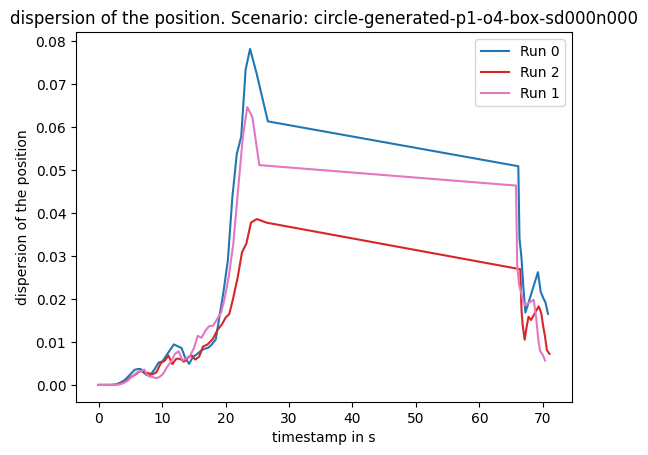

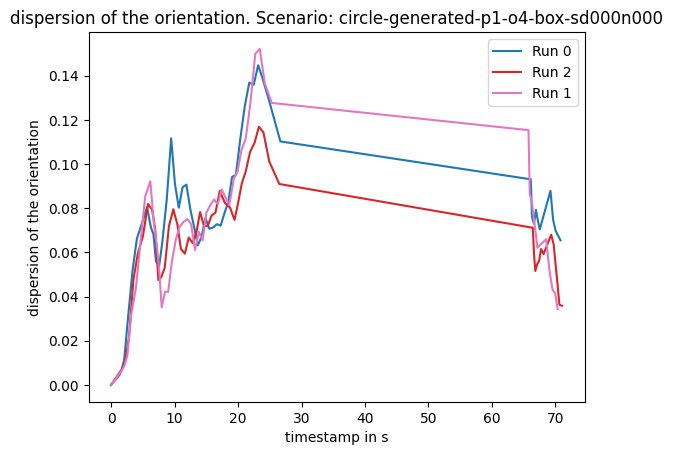

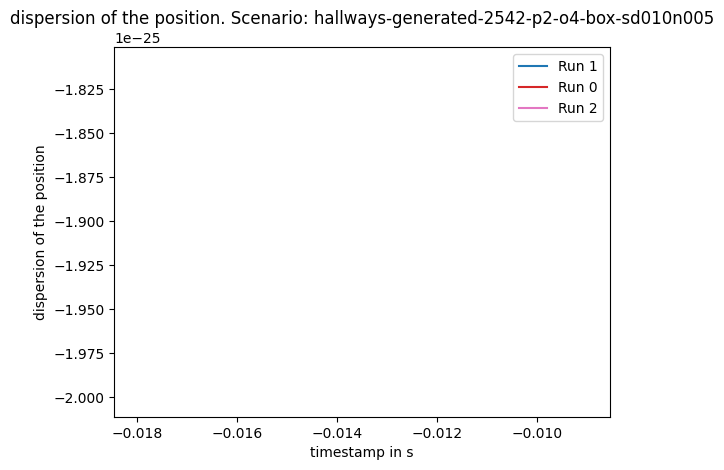

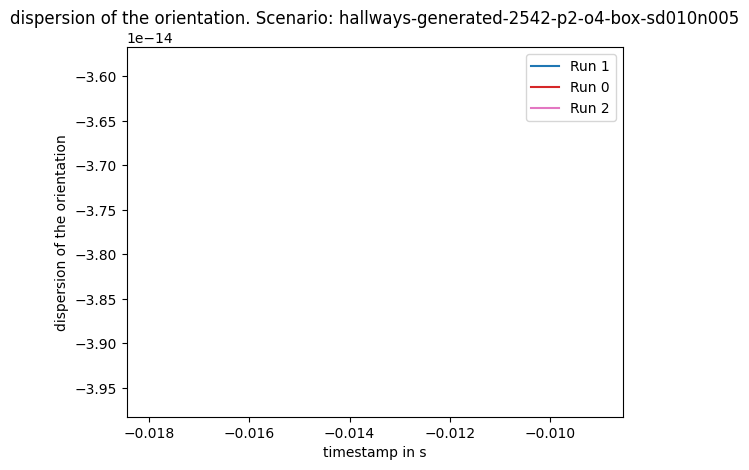

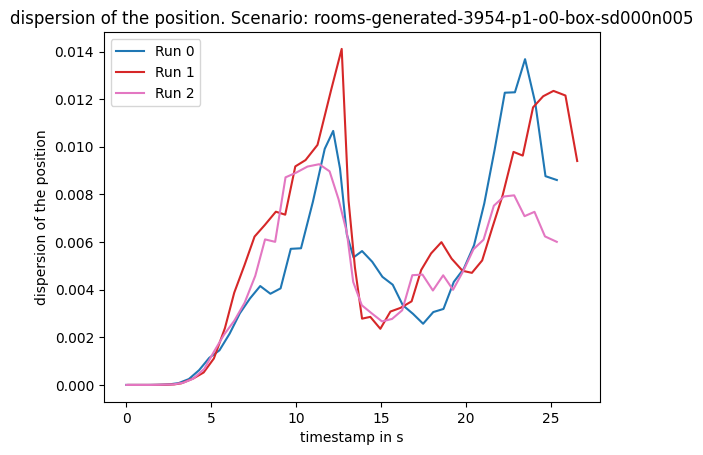

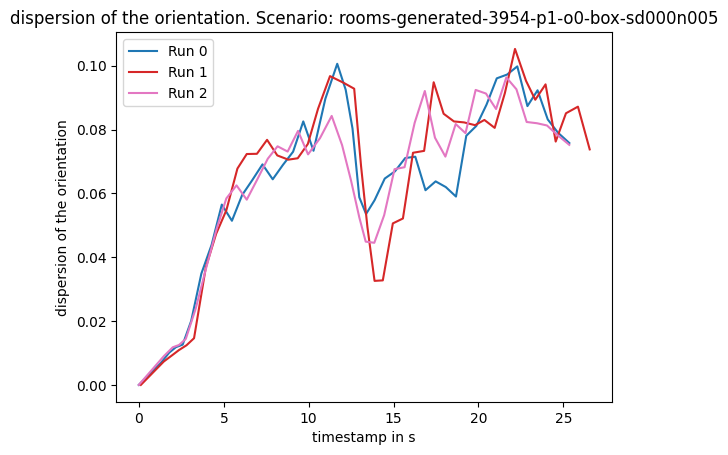

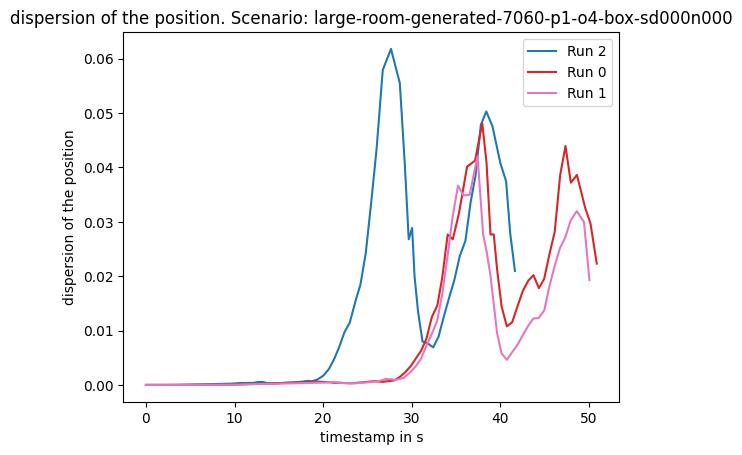

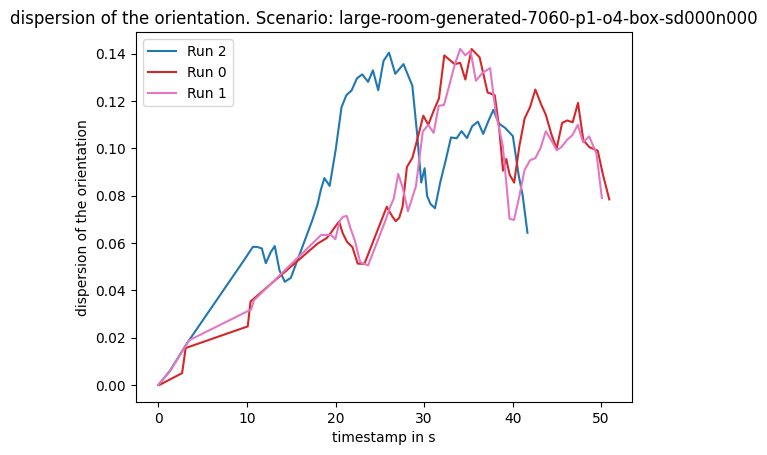

In [52]:
#Covariance analysis
#strong density equals small dispersion and good localization
#figure for means determinant covariance matrix

for i, scenario_group in enumerate(dataset):
    #we want two figure per scenario
    disp_pos_f = i*2
    disp_yaw_f = i*2 + 1
    #figures for dispersion of the position and orientation
    plt.figure(disp_pos_f) 
    plt.title('dispersion of the position. Scenario: ' +  scenario_group[0].scenario)
    plt.xlabel(TIMESTAMP + " in s")
    plt.ylabel('dispersion of the position')
        
    plt.figure(disp_yaw_f) 
    plt.title('dispersion of the orientation. Scenario: ' +  scenario_group[0].scenario)
    plt.xlabel(TIMESTAMP + " in s")
    plt.ylabel('dispersion of the orientation')
    

              
    for j, run in enumerate(scenario_group):
        t0 = run.df[TIMESTAMP].iloc[1]
        deduced_pose = run.df.loc[run.df[TOPIC] == AMCL_POSE]

        # get dispersion pose from covariance matrix
        disp_pos, disp_yaw, timestamp = get_disp_covariance(deduced_pose)
        ts = np.asarray(timestamp - t0, dtype=np.float64) 
        ts = ts / 1e9 # time in seconds

        # Plot the data of the run in scenario differentiation
        color = cmap(j / len(scenario_group) )
        plt.figure(disp_pos_f)
        plt.plot(ts, disp_pos, color=color, label=f"Run {run.run_n}")

        plt.figure(disp_yaw_f)
        plt.plot(ts, disp_yaw, color=color, label=f"Run {run.run_n}")

    plt.figure(disp_pos_f)
    plt.legend()
    plt.figure(disp_yaw_f)
    plt.legend()
